In [2]:
#Importingthelibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#visualization
import seaborn as sns

#Importingthedataset
df = pd.read_csv("cleaned (2).csv")
#listof first fiverows
df.head() 

,item_id,user_id,rating,timestamp,gender,category,brand,year,month,quantity,unitprice,amount
0,7,131,4,36692,Female,Home Audio,Philips,2000,6,5,6360,31800
1,19,231,5,36891,Female,Camera,Canon,2000,12,10,9955,99550
2,14,233,5,36893,Female,Camera,Kodak,2001,1,9,7639,68751
3,14,257,5,36926,Female,Camera,Kodak,2001,2,7,5097,35679
4,14,269,5,36952,Female,Camera,Kodak,2001,3,10,6472,64720


In [3]:
#listof last fiverows
df.tail() 

,item_id,user_id,rating,timestamp,gender,category,brand,year,month,quantity,unitprice,amount
45161,7828,1157458,5,43341,Female,Headphones,Bose,2018,8,7,5925,41475
45162,8624,1157504,5,43342,Female,Headphones,Pyle,2018,8,7,9717,68019
45163,9513,1157527,5,43344,Male,Headphones,Mpow,2018,9,8,9197,73576
45164,9125,1157555,3,43348,Female,Headphones,EldHus,2018,9,10,8848,88480
45165,9478,1157632,1,43374,Female,Headphones,Etre Jeune,2018,10,7,7717,54019


In [4]:
# shape
df.shape

(45166, 12)

In [5]:
# It is also a good practice to know the columns and their corresponding data types
# along with finding whether they contain null values or not.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45166 entries, 0 to 45165
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   item_id    45166 non-null  int64 
 1   user_id    45166 non-null  int64 
 2   rating     45166 non-null  int64 
 3   timestamp  45166 non-null  int64 
 4   gender     45166 non-null  object
 5   category   45166 non-null  object
 6   brand      45166 non-null  object
 7   year       45166 non-null  int64 
 8   month      45166 non-null  int64 
 9   quantity   45166 non-null  int64 
 10  unitprice  45166 non-null  int64 
 11  amount     45166 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 4.1+ MB


In [6]:
# to get a better understanding of the dataset,
# wecan also see the statistical summary of the dataset.
df['rating'].describe()

count    45166.000000
mean         4.218594
std          1.221118
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

In [7]:
# Wecanalso see the number of unique users and items in the dataset.
df.nunique()

item_id       1892
user_id      40401
rating           5
timestamp     4179
gender           2
category        10
brand           50
year            19
month           12
quantity         6
unitprice     5001
amount       19611
dtype: int64

In [8]:
# check for missing values
df.isnull().sum()

item_id      0
user_id      0
rating       0
timestamp    0
gender       0
category     0
brand        0
year         0
month        0
quantity     0
unitprice    0
amount       0
dtype: int64

# Data Using Visualizations

<Axes: title={'center': 'YearWise Sales'}, xlabel='year'>

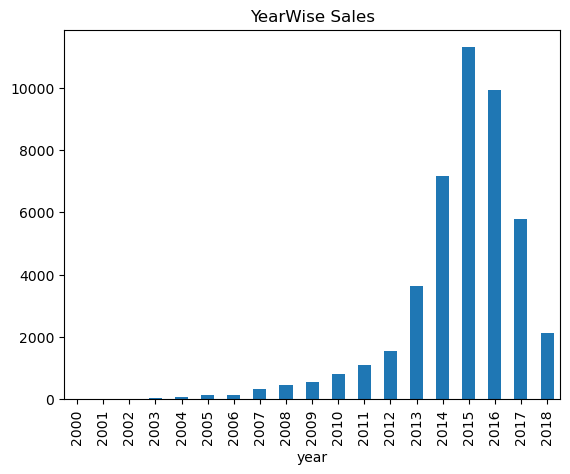

In [10]:
#  i.) What was the best year of sales?

# what was the best year of sales
df.groupby('year')['amount'].count().plot(kind='bar',title='YearWise Sales')

<Axes: xlabel='month'>

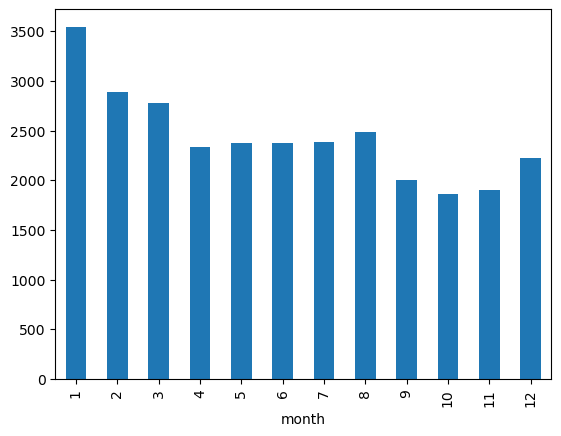

In [11]:
#  ii.) Which was the best month for sales between 2015 t0 2018

# We can see that the year 2015 to 2018 had the best sales.
# what was the best month of sales
dataset_2015_2018 = df[(df['year'] >= 2015) & (df['year'] <= 2018)]
dataset_2015_2018.groupby('month')['rating'].count().plot(kind='bar')

<Axes: title={'center': 'Brand Wise Top 10 Sales 2015 to2018'}, xlabel='brand'>

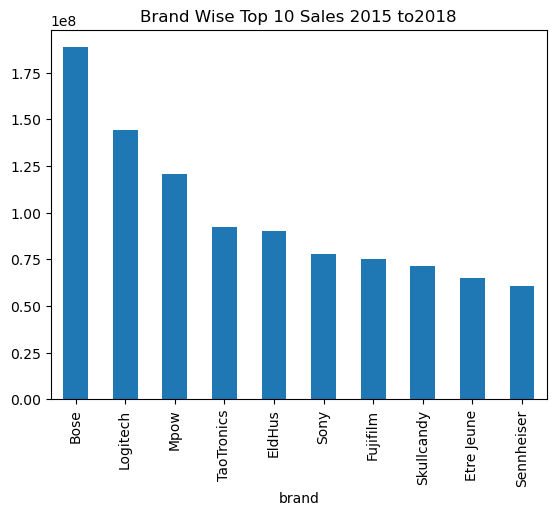

In [13]:
#  iii.) What brand sold the most in the highest selling year(2015 to 2018)
# what brand sold the most in 2015 to 2018
dataset_2015_2018 = df[(df['year'] >= 2015) & (df['year'] <= 2018)]
dataset_2015_2018.groupby('brand')['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',title='Brand Wise Top 10 Sales 2015 to2018',y='amount')

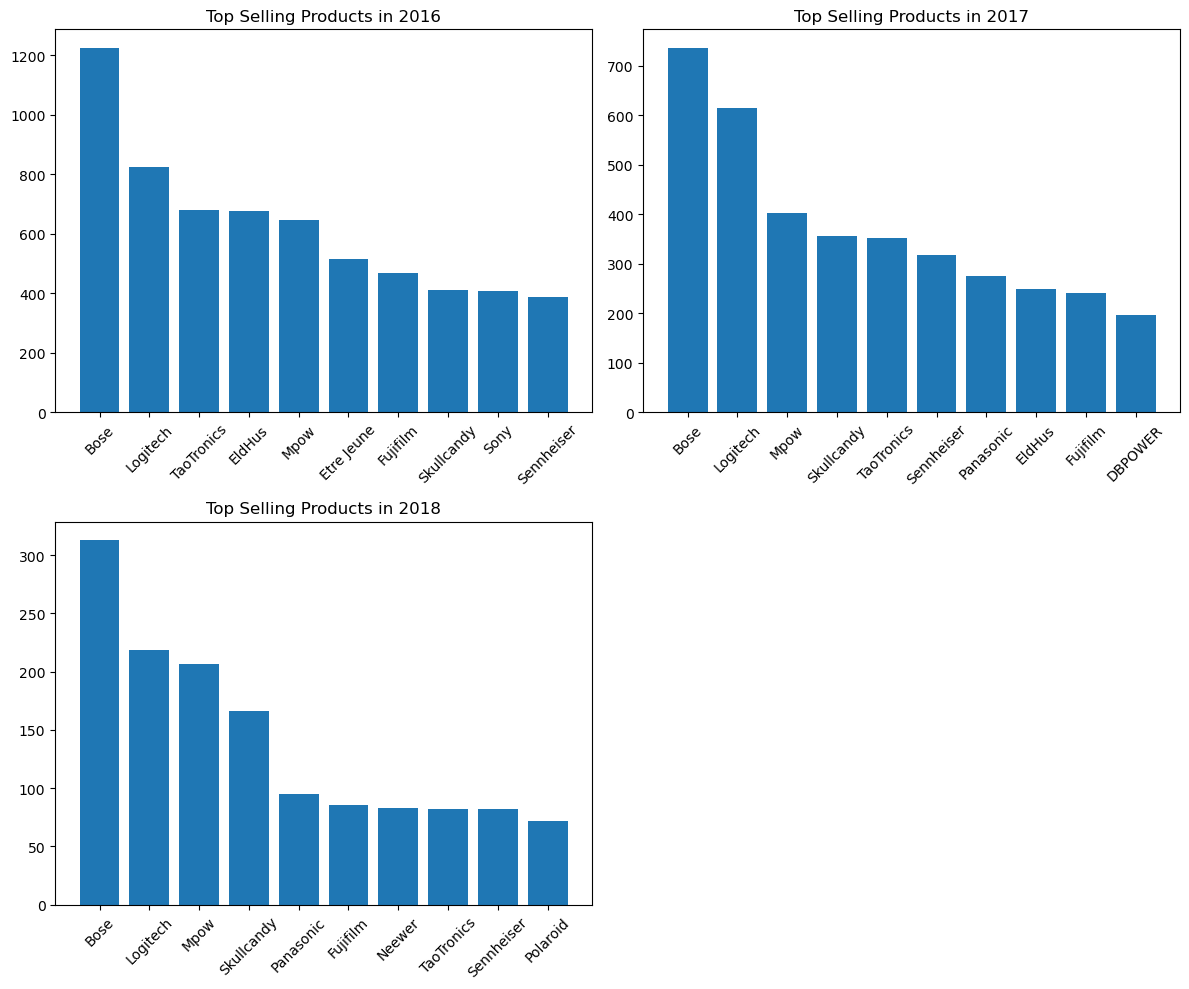

In [21]:
#  iv.) What products sold the most in the three years 2016, 2017 & 2018

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot for 2016
top_selling_2016 = df[df['year'] == 2016].groupby('brand')['rating'].count().sort_values(ascending=False).head(10)
axs[0, 0].bar(top_selling_2016.index, top_selling_2016)
axs[0, 0].set_title('Top Selling Products in 2016')
axs[0, 0].tick_params(axis='x', rotation=45) # Rotate x-axis labels

# Plot for 2017
top_selling_2017 = df[df['year'] == 2017].groupby('brand')['rating'].count().sort_values(ascending=False).head(10)
axs[0, 1].bar(top_selling_2017.index, top_selling_2017)
axs[0, 1].set_title('Top Selling Products in 2017')
axs[0, 1].tick_params(axis='x', rotation=45) # Rotate x-axis labels

 # Plot for 2018
top_selling_2018 = df[df['year'] == 2018].groupby('brand')['rating'].count().sort_values(ascending=False).head(10)
axs[1, 0].bar(top_selling_2018.index, top_selling_2018)
axs[1, 0].set_title('Top Selling Products in 2018')
axs[1, 0].tick_params(axis='x', rotation=45) # Rotate x-axis labels

# Hide the empty subplot
axs[1, 1].axis('off')

# Adjust layout for better appearance
plt.tight_layout()

# Show the plots
plt.show()

<Axes: title={'center': 'Top 10 Most Sold ProductCategory 2015 to 2018'}, xlabel='category'>

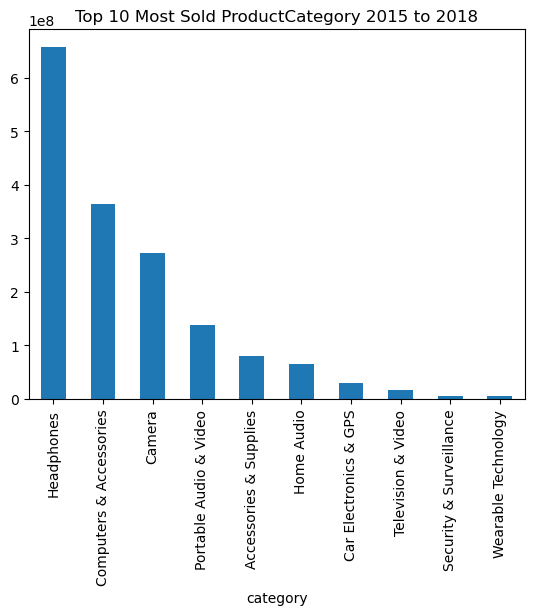

In [24]:
# v.) What product by category sold the most between 2015 to 2018?

# # What product by category sold the most between 2015 to 2018?
dataset2015_2018 = df[(df['year'] >= 2015) & (df['year'] <= 2018)]
dataset2015_2018.groupby('category')['amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar',title='Top 10 Most Sold ProductCategory 2015 to 2018')

<Axes: title={'center': '10 Least Sold Product Brand2015 to 2018'}, xlabel='category'>

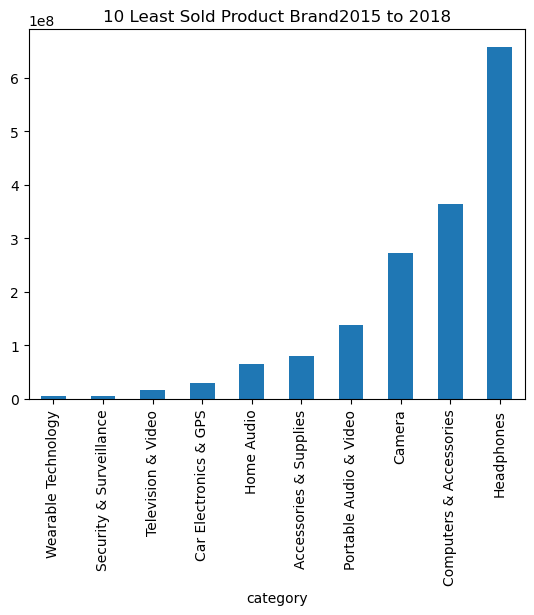

In [25]:
# vi.)What product by category sold the least between 2015 to 2018?

# What product by brand name sold the least between 2015 to 2018?
dataset2015_2018 = df[(df['year'] >= 2015) & (df['year'] <= 2018)]
dataset2015_2018.groupby('category')['amount'].sum().sort_values(ascending=True).head(10).plot(kind='bar',title='10 Least Sold Product Brand2015 to 2018')

<Axes: title={'center': '10 Least Sold Product Brand 2015to 2018'}, xlabel='brand'>

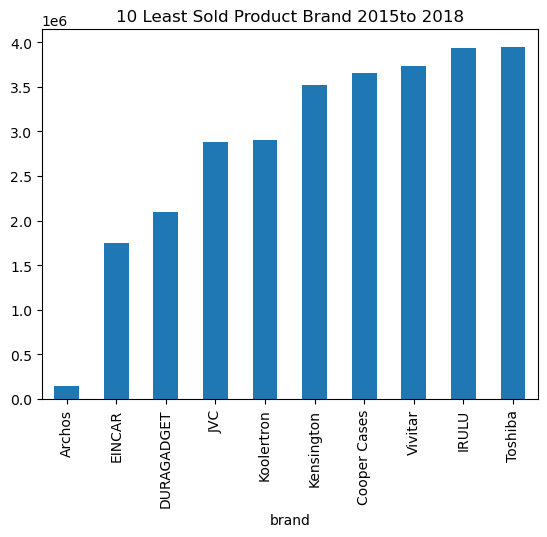

In [26]:
# vii.) What product by brand name sold the least between 2015 to 2018?

# What product by brand name sold the least between 2015 to 2018?
dataset2015_2018 = df[(df['year'] >= 2015) & (df['year'] <= 2018)]
dataset2015_2018.groupby('brand')['amount'].sum().sort_values(ascending=True).head(10).plot(kind='bar',title='10 Least Sold Product Brand 2015to 2018')

<Axes: xlabel='rating', ylabel='count'>

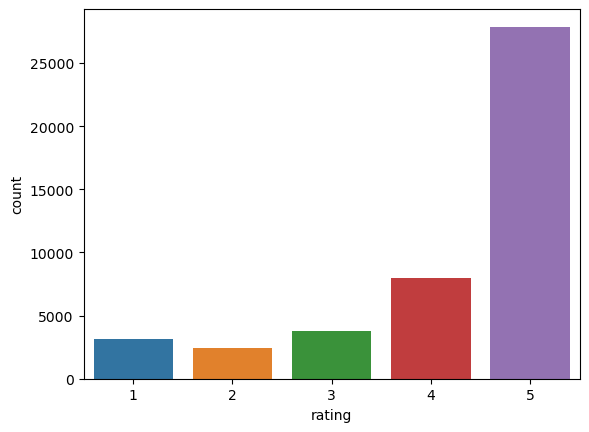

In [28]:
# viii.) Ratings Distribution

# # the distribution of ratings
sns.countplot(x='rating', data=df)

<Axes: title={'center': '10 most rating Brand 2015 to2018'}, xlabel='brand'>

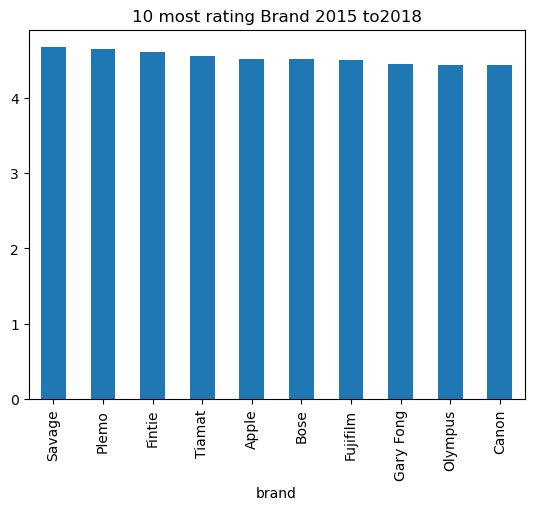

In [29]:
#  ix.) Best rated brands

# What is the most rated brand name between 2015 to 2018?
dataset2015_2018 = df[(df['year'] >= 2015) & (df['year'] <= 2018)]
dataset2015_2018.groupby('brand')['rating'].mean().sort_values(ascending=False).head(10).plot(kind='bar',title='10 most rating Brand 2015 to2018')

<Axes: title={'center': 'Top 5 category salespercentage'}, ylabel='amount'>

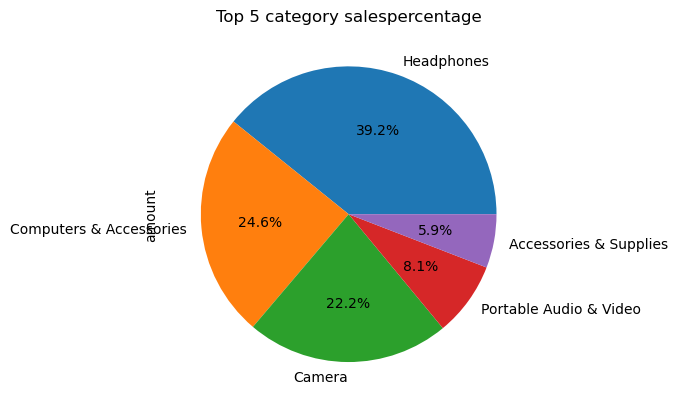

In [30]:
# x) Top 5 category sales percentage

# category percentage sales
df.groupby('category')['amount'].sum().sort_values(ascending=False).head(5).plot(kind='pie', autopct='%1.1f%%',title='Top 5 category salespercentage')

<Axes: title={'center': 'Top 5 Brand wise sales percentage'}, ylabel='rating'>

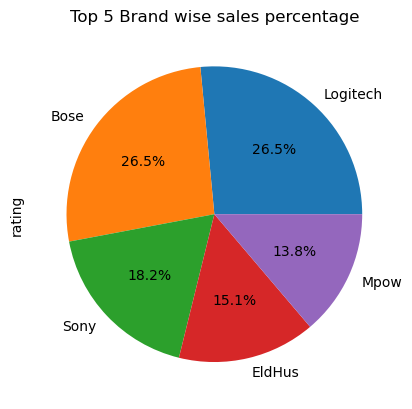

In [31]:
#  xi) Brand wise sales percentage

# brand wise sales percentage
df.groupby('brand')['rating'].count().sort_values(ascending=False).head(5).plot(kind='pie', autopct='%1.1f%%',title='Top 5 Brand wise sales percentage')

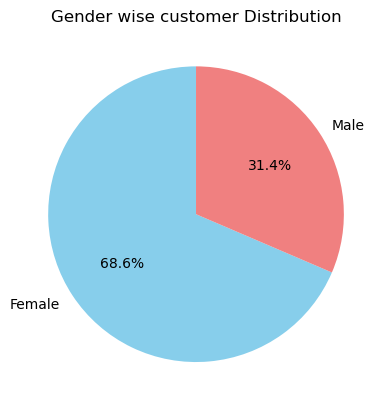

In [33]:
#  xii) Gender wise customer distribution

# Gender wise customer distribution
gender_distribution = df['gender'].value_counts()
plt.pie(gender_distribution, labels=gender_distribution.index,
autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Gender wise customer Distribution')
plt.show()

Conclusion:
● 2015wasthe best year in terms of sales and profit
● Headphones was the category with most sales followed closely with
 Computer and Accessories while the least sales were made in the Category
 Security & Surveillance.
● There has been a steady rise in sales from 2007 to 2015 and a sharp decline
 from 2016 to 2018.
● Thebrand name Bose sold the most followed by Logitech.
● Thebrand Archos sold the least followed closely with EINCAR..
● Mostproducts were rated 5.
● Bestrated brands were Savage and Plemo.